# **CHURN PREDICTION**

Customer churn directly impacts profitability because acquiring new customers is often more expensive than retaining existing ones.

This project aims to:

- Identify customers likely to churn
- Understand behavioral drivers behind churn
- Estimate revenue at risk
- Recommend targeted retention strategies

In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [25]:
df = pd.read_pickle("Dataset/Cleaned_data/master_df.pkl")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CustomerID             52924 non-null  str           
 1   Transaction_ID         52924 non-null  str           
 2   Transaction_Date       52924 non-null  datetime64[us]
 3   Month                  52924 non-null  str           
 4   Date                   52924 non-null  object        
 5   Week                   52924 non-null  str           
 6   Product_SKU            52924 non-null  str           
 7   Product_Description    52924 non-null  str           
 8   Product_Category       52924 non-null  str           
 9   ABC                    52924 non-null  str           
 10  Quantity               52924 non-null  int64         
 11  Avg_Price              52924 non-null  float64       
 12  Delivery_Charges       52924 non-null  float64       
 13  Revenue     

## Time-Based Data Split

To avoid data leakage, the dataset is split chronologically:

- **Calibration Period (`cal_df`)**: Historical transactions used for feature engineering.
- **Holdout Period (`holdout_df`)**: The most recent 90 days, used to define churn labels.
- **Recent Window (`recent_df`)**: The last 30 days before `cutoff_date`, used to capture short-term customer behavior.

This setup ensures the model learns from past behavior and predicts future churn.

In [26]:
# 1. TIME SPLIT
# =========================================================
df['Transaction_Date'] = pd.to_datetime(
    df['Transaction_Date']
)

end_date = df['Transaction_Date'].max()
cutoff_date = end_date - pd.Timedelta(days=90)

cal_df = df[
    df['Transaction_Date'] <= cutoff_date
].copy()

holdout_df = df[
    df['Transaction_Date'] > cutoff_date
].copy()


# recent 30 days
recent_cutoff = cutoff_date - pd.Timedelta(days=30)

recent_df = cal_df[
    cal_df['Transaction_Date'] >= recent_cutoff
].copy()

## Customer Behavioral Features

We engineer features to capture (similar to CLV_prediction):

- Purchase frequency → customer engagement

- Recency → inactivity signal

- Spending behavior → customer value

- Purchase momentum → behavioral change

Customers with declining momentum often exhibit higher churn risk.

In [27]:
# 2. FEATURE ENGINEERING
# =========================================================
features = cal_df.groupby(
    'CustomerID'
).agg(

    first_purchase=('Transaction_Date', 'min'),
    last_purchase=('Transaction_Date', 'max'),

    frequency_cal=('Transaction_Date', 'nunique'),
    monetary_sum=('total_revenue', 'sum'),

    total_quantity=('Quantity', 'sum'),
    unique_categories=('Product_Category', 'nunique'),

    avg_discount=('Discount_pct', 'mean'),
    coupon_usage_rate=('Is_Used_Coupon', 'mean'),

    total_delivery_fee=('Delivery_Charges', 'sum'),

    total_offline=('Offline_Spend', 'sum'),
    total_online=('Online_Spend', 'sum'),

    total_marketing=(
        'Total_Marketing_Spend',
        'sum'
    ),

    Tenure_Months=('Tenure_Months', 'first'),

    Gender=('Gender', 'first'),
    Location=('Location', 'first'),

    KMeans_Label=('KMeans_Label', 'first')

).reset_index()


# =========================================================
# 3. CUSTOMER BEHAVIOR FEATURES
# =========================================================
features['recency_cal'] = (
    cutoff_date - features['last_purchase']
).dt.days

features['T_cal'] = (
    cutoff_date - features['first_purchase']
).dt.days

features['monetary_avg'] = (
    features['monetary_sum'] /
    (features['frequency_cal'] + 1)
)

features['avg_order_interval'] = (
    features['T_cal'] /
    (features['frequency_cal'] + 1)
)


# =========================================================
# 4. RECENT TREND FEATURES
# =========================================================
recent_features = recent_df.groupby(
    'CustomerID'
).agg(

    freq_last30=('Transaction_Date', 'nunique'),
    spend_last30=('total_revenue', 'sum'),
    qty_last30=('Quantity', 'sum')

).reset_index()


features = pd.merge(
    features,
    recent_features,
    on='CustomerID',
    how='left'
)

trend_cols = [
    'freq_last30',
    'spend_last30',
    'qty_last30'
]

features[trend_cols] = (
    features[trend_cols]
    .fillna(0)
)


# =========================================================
# 5. MOMENTUM FEATURES
# =========================================================
features['purchase_momentum'] = (
    features['freq_last30'] /
    (features['frequency_cal'] + 1)
)

features['spend_momentum'] = (
    features['spend_last30'] /
    (features['monetary_sum'] + 1)
)


# =========================================================
# 6. DROP DATE COLUMNS
# =========================================================
features = features.drop(
    columns=[
        'first_purchase',
        'last_purchase'
    ]
)


# =========================================================
# 7. ENCODE CATEGORICAL
# =========================================================
features = pd.get_dummies(
    features,
    columns=[
        'Gender',
        'Location',
        'KMeans_Label'
    ],
    drop_first=True
)

## Churn Target Definition

Using the 90-day **holdout period**, customers are labeled based on future transaction activity:

- **Churned (1):** No transactions during the holdout period.
- **Active (0):** At least one transaction during the holdout period.

This forward-looking labeling ensures the model predicts future churn based only on historical customer behavior.

In [28]:
# 8. CREATE FUTURE CHURN LABEL
# =========================================================
future_orders = holdout_df.groupby(
    'CustomerID'
).agg(
    future_orders=(
        'Transaction_ID',
        'nunique'
    )
).reset_index()


# Merge all customers
churn_df = pd.merge(
    features,
    future_orders,
    on='CustomerID',
    how='left'
)

churn_df['future_orders'] = (
    churn_df['future_orders']
    .fillna(0)
)

# If no purchase in next 90 days => churn
churn_df['Churn'] = (
    churn_df['future_orders'] == 0
).astype(int)

In [29]:
# 9. TRAIN TEST SPLIT
# =========================================================
X = churn_df.drop(
    columns=[
        'CustomerID',
        'future_orders',
        'Churn'
    ]
)

y = churn_df['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Training and Evaluation

After feature engineering and churn labeling, three classification models are trained and compared:

- **Logistic Regression**: Baseline linear model (`max_iter=1000`)
- **Random Forest**: Tree-based ensemble model (`n_estimators=200`)
- **XGBoost**: Gradient boosting model (`n_estimators=200`, `max_depth=6`, `learning_rate=0.05`)

All models use `random_state=42` for reproducibility.

### Training and Evaluation

Each model is trained on `X_train` and evaluated on `X_test` using:

- **Class predictions (`predict`)**
- **Churn probabilities (`predict_proba`)**

Performance is evaluated using:

- **ROC-AUC**: Measures the model’s ability to distinguish churned and active customers.
- **Precision, Recall, F1-score**: Evaluates classification performance under class imbalance.

### Feature Importance

For each model, the **top 15 important features** are extracted to identify the key drivers of customer churn.

### Final Comparison

Model performance is summarized and ranked based on **ROC-AUC** scores.

In [30]:
# 10. MODELS
# =========================================================
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            random_state=42,
            n_jobs=-1
        )
}

In [31]:
# 11. TRAIN + EVALUATE
# =========================================================
results = []

print("\n--- START CHURN TRAINING ---")

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    y_pred_proba = model.predict_proba(
        X_test
    )[:, 1]

    auc = roc_auc_score(
        y_test,
        y_pred_proba
    )

    results.append({
        "Model": name,
        "ROC-AUC": auc
    })

    print(
        f"ROC-AUC: {auc:.4f}"
    )

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # Feature importance for all models
    if name == "Logistic Regression":

        importance = pd.DataFrame({
            "feature": X.columns,
            "importance": np.abs(model.coef_[0])
        })

    else:  # Random Forest + XGBoost

        importance = pd.DataFrame({
            "feature": X.columns,
            "importance": model.feature_importances_
        })

    importance = importance.sort_values(
        by="importance",
        ascending=False
    )

    print(f"\nTop 15 Important Features - {name}:")
    print(
        importance.head(15)
    )


# =========================================================
# 12. FINAL RESULTS
# =========================================================
results_df = pd.DataFrame(
    results
).sort_values(
    by='ROC-AUC',
    ascending=False
)

print("\n--- FINAL RESULTS ---")
print(
    results_df.to_string(
        index=False
    )
)


--- START CHURN TRAINING ---

Training Logistic Regression...


C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC-AUC: 0.6318
              precision    recall  f1-score   support

           0       0.67      0.21      0.32        57
           1       0.80      0.97      0.88       186

    accuracy                           0.79       243
   macro avg       0.73      0.59      0.60       243
weighted avg       0.77      0.79      0.75       243


Top 15 Important Features - Logistic Regression:
               feature  importance
10       Tenure_Months    0.016493
14  avg_order_interval    0.016036
11         recency_cal    0.008817
12               T_cal    0.007528
17          qty_last30    0.003772
3    unique_categories    0.003392
25      KMeans_Label_1    0.002141
2       total_quantity    0.001113
15         freq_last30    0.000624
19      spend_momentum    0.000454
5    coupon_usage_rate    0.000349
21    Location_Chicago    0.000294
18   purchase_momentum    0.000276
26      KMeans_Label_2    0.000245
20            Gender_M    0.000213

Training Random Forest...
ROC-AUC: 0.9571
    

## Nhận xét Kết quả Kiểm định & Lưu ý Ứng dụng (Insights & Caveats)

Sau khi tiến hành phân tích trên nhiều thuật toán, chúng ta có thể rút ra những đánh giá quan trọng về khả năng dự báo của mô hình Random Forest đối với bài toán Rời bỏ (Churn):

*1. Điểm tích cực (Khả năng phân loại và nhận diện):*
- *Khả năng phân tách sắc bén (High ROC-AUC):* Chỉ số ROC-AUC trên tập Test đạt mức *0.957*. Điều này chứng tỏ mô hình học máy đã tìm ra được ranh giới cực kỳ rõ rệt giữa một khách hàng sắp rời đi và một khách hàng sẽ tiếp tục mua sắm.
- *Bắt chẩn bệnh cực nhạy (High Recall for Churn):* Đối với nhóm khách hàng thực sự sẽ Churn, mô hình "tóm dính" được tới *96%* (Recall 0.96) với độ chính xác khi chẩn đoán là *92%* (Precision 0.92). Tổng thể giúp bộ phận Marketing nhắm trúng đích đối tượng rủi ro mà không lãng phí đạn dược.
- *Yếu tố Hành vi quyết định tất cả (Behavioral Drivers):* Nhìn vào bảng độ quan trọng (Feature Importances), mô hình đánh giá rủi ro hoàn toàn dựa vào hành vi (Số ngày vắng mặt, Nhịp độ mua sắm, Cụm phân khúc) thay vì nhân khẩu học. Điều này rất thực tế dưới góc độ kinh doanh: "Khách hàng làm gì quan trọng hơn họ là ai".

*2. Hạn chế của mô hình (Những rủi ro tiềm ẩn):*
Mặc dù xuất sắc, thuật toán phân loại (Classification) này vẫn bộc lộ những khuyết điểm đặc thù mà chúng ta cần dè chừng:
- *Dự báo nhầm khách hàng Active thành Churn (False Positives):* Chỉ số Recall ở nhóm khách hàng Active chỉ đạt 74%. Nghĩa là mô hình có xu hướng hơi "bi quan", đôi khi sẽ gán nhãn Churn cho những người vốn dĩ định tiếp tục mua sắm. Điều này rất nguy hiểm cho Marketing, vì nếu tặng mã giảm giá cho những người định tự bỏ tiền ra mua, doanh nghiệp sẽ bị "ăn lẹm" vào lợi nhuận biên (Margin erosion).
- *Hiện tượng Overfitting nhẹ:* Chỉ số Train ROC-AUC là 1.0 (hoàn hảo) trong khi Test là 0.957. Mô hình đang có dấu hiệu học "hơi vẹt" dữ liệu lịch sử. Do đó, nếu thị trường xuất hiện các cú sốc ngoại cảnh làm thay đổi hoàn toàn hành vi tiêu dùng, mô hình có thể sẽ mất đi độ nhạy bén.

*3. Đề xuất & Lưu ý khi ứng dụng vào thực tế:*
Nếu sử dụng danh sách dự báo Churn này để chạy các chiến dịch Cứu vãn (Win-back) trong tương lai, cần lưu ý:
- *Kiểm soát rủi ro chi phí:* Vì mô hình có tỷ lệ "nhận diện nhầm" (như đã phân tích ở trên), tuyệt đối không áp dụng mã giảm giá siêu khủng (Deep discount) một cách đại trà. Hãy kết hợp ưu đãi giá trị cao với việc kiểm tra chéo giá trị CLV dự báo của họ trước đó.
- *Độ trễ của cảnh báo (Lagging Indicator):* Khách hàng vắng mặt càng lâu (recency_cal cao) thì mô hình dự báo Churn càng chuẩn. Nhưng đứng ở góc độ kinh doanh, khi họ đi quá lâu rồi mới báo động thì đã hơi muộn màng để níu kéo.
- *Hướng cải thiện (Next steps):* Trong các phiên bản mô hình tiếp theo, có thể thử nghiệm loại bỏ hoặc làm mờ đi trọng số của biến Recency. Việc này ép mô hình phải tập trung tìm ra rủi ro rời bỏ ở các giai đoạn cực sớm (early-warning) dựa trên sự sụt giảm của đà mua sắm (purchase_momentum) ngay khi khách hàng mới chỉ chớm có dấu hiệu chán nản.

In [32]:
best_model = models["Random Forest"]

train_auc = roc_auc_score(
    y_train,
    best_model.predict_proba(X_train)[:,1]
)

test_auc = roc_auc_score(
    y_test,
    best_model.predict_proba(X_test)[:,1]
)

print("Train ROC-AUC:", round(train_auc, 4))
print("Test ROC-AUC:", round(test_auc, 4))

Train ROC-AUC: 1.0
Test ROC-AUC: 0.9571



--- CHURN PROBABILITY DISTRIBUTION ---
count    1211.000000
mean        0.760983
std         0.327923
min         0.005000
25%         0.642500
50%         0.940000
75%         0.995000
max         1.000000
Name: Churn_Probability, dtype: float64

Churn Probability Range:
Min: 0.0050
Max: 1.0000

--- SEGMENT DISTRIBUTION ---
Churn_Segment
High Risk      896
Low Risk       259
Medium Risk     56
Name: count, dtype: int64

Segment Percentage:
Churn_Segment
High Risk      73.988439
Low Risk       21.387283
Medium Risk     4.624277
Name: proportion, dtype: float64

--- SEGMENT CHARACTERISTICS ---
              Churn_Probability               frequency_cal monetary_sum  \
                           mean    min    max          mean         mean   
Churn_Segment                                                              
High Risk                0.9444  0.705  1.000        1.6975    2381.3562   
Low Risk                 0.1697  0.005  0.395        2.7529    3471.2403   
Medium Risk        

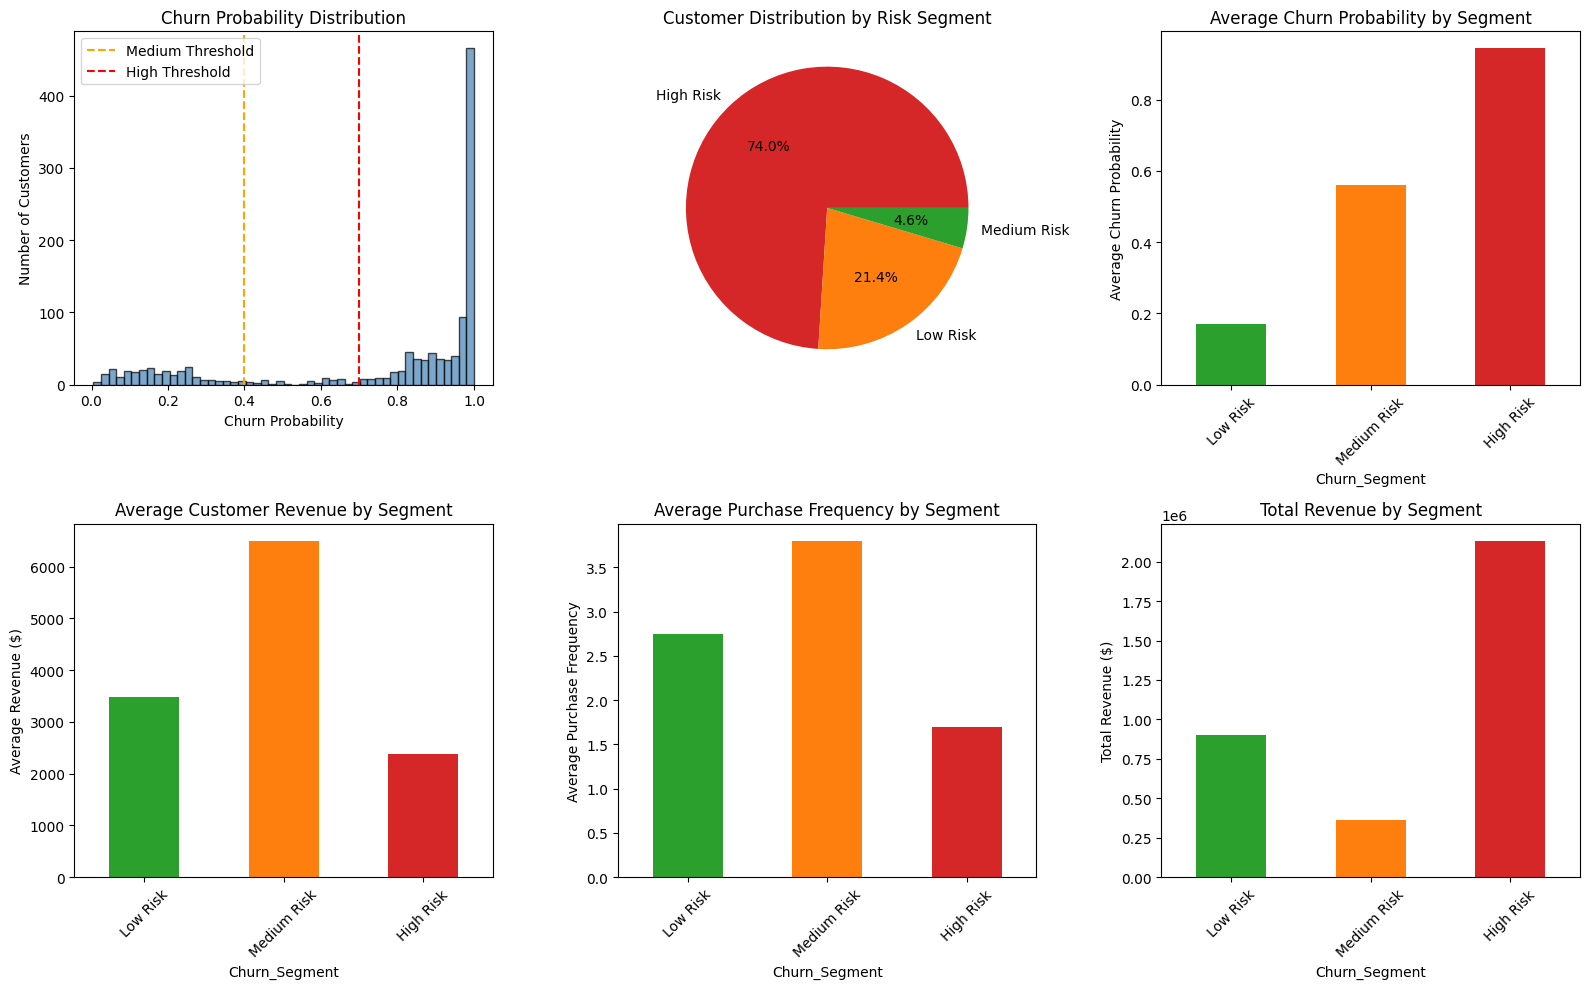


--- DETAILED SEGMENT PROFILES ---


SEGMENT: Low Risk
Customer Count: 259
Percentage of Total: 21.4%

Churn Metrics:
  - Avg Churn Probability: 16.97%
  - Actual Churn Rate: 0.77%

Behavioral Metrics:
  - Avg Purchase Frequency: 2.8
  - Avg Total Spend: $3,471.24
  - Avg Order Value: $881.49
  - Avg Recency (days): 86.1
  - Avg Tenure (months): 25.9

Engagement Metrics:
  - Avg Categories Explored: 6.5
  - Coupon Usage Rate: 34.74%
  - Avg Discount Used: 6.96%
  - Purchase Momentum: 5.22%
  - Spend Momentum: 8.13%

Revenue Metrics:
  - Total Revenue: $899,051.24
  - % of Total Revenue: 26.5%

SEGMENT: Medium Risk
Customer Count: 56
Percentage of Total: 4.6%

Churn Metrics:
  - Avg Churn Probability: 56.08%
  - Actual Churn Rate: 55.36%

Behavioral Metrics:
  - Avg Purchase Frequency: 3.8
  - Avg Total Spend: $6,503.94
  - Avg Order Value: $1,094.74
  - Avg Recency (days): 45.3
  - Avg Tenure (months): 26.5

Engagement Metrics:
  - Avg Categories Explored: 8.3
  - Coupon Usage Rate: 34

In [33]:
# =========================================================
# 13. GENERATE CHURN PROBABILITIES
# =========================================================
# Get predictions for all customers
churn_df['Churn_Probability'] = best_model.predict_proba(X)[:, 1]

# Display distribution
print("\n--- CHURN PROBABILITY DISTRIBUTION ---")
print(churn_df['Churn_Probability'].describe())

print("\nChurn Probability Range:")
print(f"Min: {churn_df['Churn_Probability'].min():.4f}")
print(f"Max: {churn_df['Churn_Probability'].max():.4f}")


# =========================================================
# 14. CREATE CHURN RISK SEGMENTS
# =========================================================
def segment_churn_risk(probability):
    """
    Assign churn risk segment based on probability
    """
    if probability >= 0.7:
        return 'High Risk'
    elif probability >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'


churn_df['Churn_Segment'] = churn_df['Churn_Probability'].apply(
    segment_churn_risk
)

# Segment distribution
print("\n--- SEGMENT DISTRIBUTION ---")
segment_counts = churn_df['Churn_Segment'].value_counts()
print(segment_counts)

segment_pct = churn_df['Churn_Segment'].value_counts(normalize=True) * 100
print("\nSegment Percentage:")
print(segment_pct)


# =========================================================
# 15. ANALYZE SEGMENT CHARACTERISTICS
# =========================================================
segment_analysis = churn_df.groupby('Churn_Segment').agg({
    'Churn_Probability': ['mean', 'min', 'max'],
    'frequency_cal': 'mean',
    'monetary_sum': 'mean',
    'recency_cal': 'mean',
    'monetary_avg': 'mean',
    'avg_order_interval': 'mean',
    'purchase_momentum': 'mean',
    'spend_momentum': 'mean',
    'Tenure_Months': 'mean',
    'total_quantity': 'mean',
    'unique_categories': 'mean',
    'avg_discount': 'mean',
    'coupon_usage_rate': 'mean',
    'total_delivery_fee': 'mean',
}).round(4)

print("\n--- SEGMENT CHARACTERISTICS ---")
print(segment_analysis)


# =========================================================
# 16. SEGMENT BUSINESS METRICS
# =========================================================
segment_metrics = churn_df.groupby('Churn_Segment').agg({
    'CustomerID': 'count',
    'monetary_sum': ['sum', 'mean'],
    'frequency_cal': 'mean',
    'Churn': 'mean',
}).round(2)

segment_metrics.columns = [
    'Customer_Count',
    'Total_Revenue',
    'Avg_Revenue_Per_Customer',
    'Avg_Frequency',
    'Actual_Churn_Rate'
]

print("\n--- BUSINESS METRICS BY SEGMENT ---")
print(segment_metrics)

# Calculate revenue at risk
total_revenue = churn_df['monetary_sum'].sum()
high_risk_revenue = churn_df[
    churn_df['Churn_Segment'] == 'High Risk'
]['monetary_sum'].sum()

revenue_at_risk_pct = (high_risk_revenue / total_revenue) * 100

print(f"\nTotal Revenue: ${total_revenue:,.2f}")
print(f"High Risk Revenue: ${high_risk_revenue:,.2f}")
print(f"Revenue at Risk: {revenue_at_risk_pct:.2f}%")


# =========================================================
# 17. VISUALIZATIONS
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Churn Probability Distribution
axes[0, 0].hist(
    churn_df['Churn_Probability'],
    bins=50,
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)
axes[0, 0].set_xlabel('Churn Probability')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].set_title('Churn Probability Distribution')
axes[0, 0].axvline(0.4, color='orange', linestyle='--', label='Medium Threshold')
axes[0, 0].axvline(0.7, color='red', linestyle='--', label='High Threshold')
axes[0, 0].legend()

# 2. Segment Distribution (Pie Chart)
segment_counts.plot(
    kind='pie',
    ax=axes[0, 1],
    autopct='%1.1f%%',
    colors=['#d62728', '#ff7f0e', '#2ca02c']
)
axes[0, 1].set_ylabel('')
axes[0, 1].set_title('Customer Distribution by Risk Segment')

# 3. Average Churn Probability by Segment
segment_avg_prob = churn_df.groupby('Churn_Segment')['Churn_Probability'].mean()
segment_avg_prob = segment_avg_prob.reindex(['Low Risk', 'Medium Risk', 'High Risk'])
segment_avg_prob.plot(
    kind='bar',
    ax=axes[0, 2],
    color=['#2ca02c', '#ff7f0e', '#d62728']
)
axes[0, 2].set_ylabel('Average Churn Probability')
axes[0, 2].set_title('Average Churn Probability by Segment')
axes[0, 2].set_xticklabels(axes[0, 2].get_xticklabels(), rotation=45)

# 4. Average Revenue by Segment
segment_revenue = churn_df.groupby('Churn_Segment')['monetary_sum'].mean()
segment_revenue = segment_revenue.reindex(['Low Risk', 'Medium Risk', 'High Risk'])
segment_revenue.plot(
    kind='bar',
    ax=axes[1, 0],
    color=['#2ca02c', '#ff7f0e', '#d62728']
)
axes[1, 0].set_ylabel('Average Revenue ($)')
axes[1, 0].set_title('Average Customer Revenue by Segment')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# 5. Average Frequency by Segment
segment_freq = churn_df.groupby('Churn_Segment')['frequency_cal'].mean()
segment_freq = segment_freq.reindex(['Low Risk', 'Medium Risk', 'High Risk'])
segment_freq.plot(
    kind='bar',
    ax=axes[1, 1],
    color=['#2ca02c', '#ff7f0e', '#d62728']
)
axes[1, 1].set_ylabel('Average Purchase Frequency')
axes[1, 1].set_title('Average Purchase Frequency by Segment')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)

# 6. Revenue at Risk (Stacked Bar)
segment_revenue_total = churn_df.groupby('Churn_Segment')['monetary_sum'].sum()
segment_revenue_total = segment_revenue_total.reindex(['Low Risk', 'Medium Risk', 'High Risk'])
segment_revenue_total.plot(
    kind='bar',
    ax=axes[1, 2],
    color=['#2ca02c', '#ff7f0e', '#d62728']
)
axes[1, 2].set_ylabel('Total Revenue ($)')
axes[1, 2].set_title('Total Revenue by Segment')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


# =========================================================
# 18. SEGMENT PROFILES (DETAILED)
# =========================================================
print("\n--- DETAILED SEGMENT PROFILES ---\n")

for segment in ['Low Risk', 'Medium Risk', 'High Risk']:
    segment_data = churn_df[churn_df['Churn_Segment'] == segment]
    
    print(f"\n{'='*60}")
    print(f"SEGMENT: {segment}")
    print(f"{'='*60}")
    
    print(f"Customer Count: {len(segment_data):,}")
    print(f"Percentage of Total: {len(segment_data)/len(churn_df)*100:.1f}%")
    
    print(f"\nChurn Metrics:")
    print(f"  - Avg Churn Probability: {segment_data['Churn_Probability'].mean():.2%}")
    print(f"  - Actual Churn Rate: {segment_data['Churn'].mean():.2%}")
    
    print(f"\nBehavioral Metrics:")
    print(f"  - Avg Purchase Frequency: {segment_data['frequency_cal'].mean():.1f}")
    print(f"  - Avg Total Spend: ${segment_data['monetary_sum'].mean():,.2f}")
    print(f"  - Avg Order Value: ${segment_data['monetary_avg'].mean():,.2f}")
    print(f"  - Avg Recency (days): {segment_data['recency_cal'].mean():.1f}")
    print(f"  - Avg Tenure (months): {segment_data['Tenure_Months'].mean():.1f}")
    
    print(f"\nEngagement Metrics:")
    print(f"  - Avg Categories Explored: {segment_data['unique_categories'].mean():.1f}")
    print(f"  - Coupon Usage Rate: {segment_data['coupon_usage_rate'].mean():.2%}")
    print(f"  - Avg Discount Used: {segment_data['avg_discount'].mean():.2%}")
    print(f"  - Purchase Momentum: {segment_data['purchase_momentum'].mean():.2%}")
    print(f"  - Spend Momentum: {segment_data['spend_momentum'].mean():.2%}")
    
    print(f"\nRevenue Metrics:")
    total_segment_revenue = segment_data['monetary_sum'].sum()
    pct_of_total = total_segment_revenue / total_revenue * 100
    print(f"  - Total Revenue: ${total_segment_revenue:,.2f}")
    print(f"  - % of Total Revenue: {pct_of_total:.1f}%")

In [37]:
churn_df.to_pickle("Output/churn_df.pkl")

**Cohort Analysis**

We construct cohorts based on the month of first purchase to study retention. By pivoting a cohort table (cohort index vs month offset), we measure retention rates over time.


--- COHORT INSIGHTS ---
Total valid cohorts: 12
Min cohort size: 68.0
Max cohort size: 215.0

Best Month-2 Cohort: 2019-06
Retention Rate: 14.60%

Worst Month-2 Cohort: 2019-01
Retention Rate: 6.05%

Average Retention by Month:
Month 1: 100.00%
Month 2: 9.68%
Month 3: 10.29%
Month 4: 10.89%
Month 5: 11.51%
Month 6: 14.66%
Month 7: 12.53%
Month 8: 13.37%
Month 9: 9.76%
Month 10: 11.74%
Month 11: 12.98%
Month 12: 15.81%


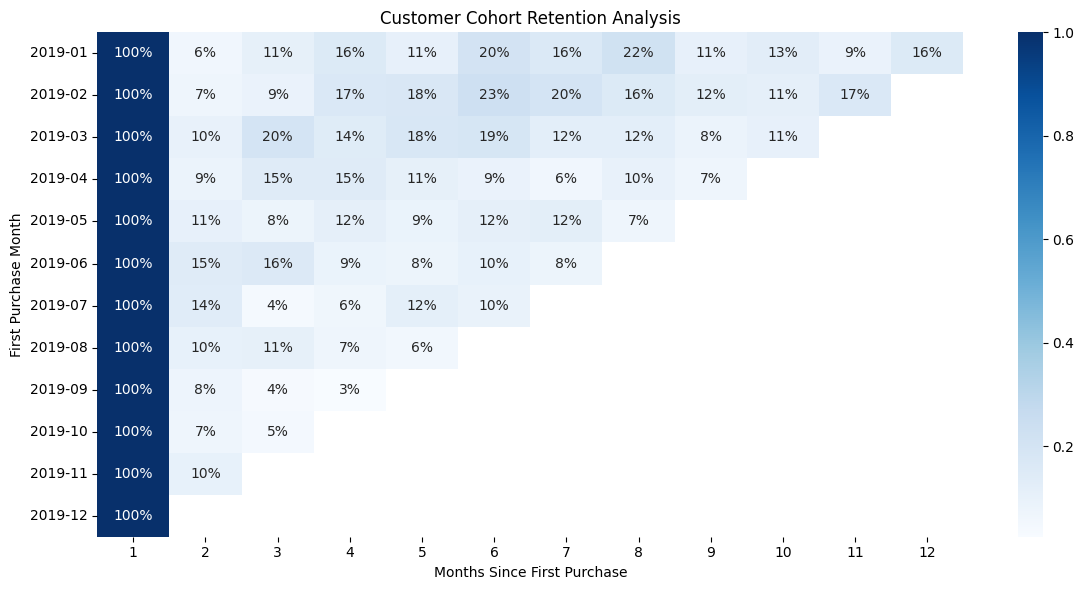

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. PREPARE DATE
# =========================================================
df['Transaction_Date'] = pd.to_datetime(
    df['Transaction_Date']
)


# =========================================================
# 2. CREATE PURCHASE MONTH
# =========================================================
df['PurchaseMonth'] = (
    df['Transaction_Date']
    .dt.to_period('M')
)


# =========================================================
# 3. DEFINE CUSTOMER COHORT
# =========================================================
# Cohort = first month customer appears
df['CohortMonth'] = (

    df.groupby(
        'CustomerID'
    )['PurchaseMonth']

    .transform(
        'min'
    )
)


# =========================================================
# 4. COUNT ACTIVE CUSTOMERS
# =========================================================
cohort_data = (

    df.groupby(
        [
            'CohortMonth',
            'PurchaseMonth'
        ]
    )['CustomerID']

    .nunique()

    .reset_index()
)


# =========================================================
# 5. CALCULATE COHORT PERIOD
# =========================================================
cohort_data['CohortPeriod'] = (

    (
        cohort_data['PurchaseMonth'].dt.year -
        cohort_data['CohortMonth'].dt.year
    ) * 12

    +

    (
        cohort_data['PurchaseMonth'].dt.month -
        cohort_data['CohortMonth'].dt.month
    )

    + 1
)


# =========================================================
# 6. CREATE COHORT MATRIX
# =========================================================
cohort_counts = cohort_data.pivot(

    index='CohortMonth',
    columns='CohortPeriod',
    values='CustomerID'
)


# =========================================================
# 7. CALCULATE RETENTION RATE
# =========================================================
cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
)


# =========================================================
# 8. REMOVE VERY SMALL COHORTS
# =========================================================
# avoid noisy cohorts
min_customers = 20

valid_cohorts = cohort_sizes[
    cohort_sizes >= min_customers
].index

retention = retention.loc[
    valid_cohorts
]

cohort_sizes = cohort_sizes.loc[
    valid_cohorts
]


# =========================================================
# 9. BUSINESS INSIGHTS
# =========================================================
print("\n--- COHORT INSIGHTS ---")

print(
    f"Total valid cohorts: {len(retention)}"
)

print(
    f"Min cohort size: {cohort_sizes.min()}"
)

print(
    f"Max cohort size: {cohort_sizes.max()}"
)


# month 2 retention
if 2 in retention.columns:

    best_cohort = retention[2].idxmax()
    worst_cohort = retention[2].idxmin()

    best_retention = retention.loc[
        best_cohort,
        2
    ]

    worst_retention = retention.loc[
        worst_cohort,
        2
    ]

    print(
        f"\nBest Month-2 Cohort: "
        f"{best_cohort}"
    )

    print(
        f"Retention Rate: "
        f"{best_retention:.2%}"
    )

    print(
        f"\nWorst Month-2 Cohort: "
        f"{worst_cohort}"
    )

    print(
        f"Retention Rate: "
        f"{worst_retention:.2%}"
    )


# Average retention
avg_retention = retention.mean()

print("\nAverage Retention by Month:")

for month, value in avg_retention.items():

    print(
        f"Month {month}: "
        f"{value:.2%}"
    )


# =========================================================
# 10. VISUALIZATION
# =========================================================
plt.figure(
    figsize=(12, 6)
)

sns.heatmap(

    retention,

    annot=True,
    fmt=".0%",

    cmap="Blues"
)

plt.title(
    "Customer Cohort Retention Analysis"
)

plt.ylabel(
    "First Purchase Month"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.tight_layout()
plt.show()